In [1]:
"""
Created on June 
"""

'\nCreated on June \n'

In [2]:
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
from scipy.stats import ks_2samp
from datetime import datetime, time
import glob
import os
from pathlib import Path

In [6]:
# ============================================================
# CONFIG — only cell to edit if you move the project
# ============================================================
from pathlib import Path

# Project root = 2 levels up from preprocessing/ folder
ROOT = Path("../").resolve()

# Input paths

ROOT      = Path("../").resolve()
cpid_path = ROOT / "data" / "infos_cpids"
base_path = ROOT / "data" / "Sessions_from_ChargePlaceScotland"
# Output paths
OUTPUT_DIR = ROOT / "data" / "Master file scotland dataset"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f" Project root: {ROOT}")
print(f" CPID data:    {cpid_path}")
print(f" Sessions:     {base_path}")
print(f" Output:       {OUTPUT_DIR}")


 Project root: C:\Users\Lenovo\Downloads\Spatio-Temporal-Modelling-of-Electric-Vehicle-Charging-Demand
 CPID data:    C:\Users\Lenovo\Downloads\Spatio-Temporal-Modelling-of-Electric-Vehicle-Charging-Demand\data\infos_cpids
 Sessions:     C:\Users\Lenovo\Downloads\Spatio-Temporal-Modelling-of-Electric-Vehicle-Charging-Demand\data\Sessions_from_ChargePlaceScotland
 Output:       C:\Users\Lenovo\Downloads\Spatio-Temporal-Modelling-of-Electric-Vehicle-Charging-Demand\data\Master file scotland dataset


In [7]:
# cpid_path is already set in the CONFIG cell above — nothing to change here
print(f"Using CPID path: {cpid_path}")


Using CPID path: C:\Users\Lenovo\Downloads\Spatio-Temporal-Modelling-of-Electric-Vehicle-Charging-Demand\data\infos_cpids


In [8]:
#bringing in ChargerID and LA data
ChargerID     = pd.read_excel(cpid_path / 'CPID_and_local_authority.xlsx')
#correcting erroneous entries
ChargerID.loc[ChargerID['CPID']==61625, 'local_authority'] = 'Renfrewshire'
ChargerID.loc[ChargerID['CPID']=='CMU2211', 'local_authority'] = 'North Lanarkshire'


In [9]:
#bringing in charging speed data
ChargerSpeeds = pd.read_excel(cpid_path / 'CPID_and_charger_speed.xlsx')

In [10]:
# DEFINE FILENAMES (Soft-coded)
# This list maintains the exact order you provided
files = [
    "Oct22.xlsx", "Nov22.xlsx", "Dec22.xlsx", 
    "Jan23.xlsx", "Feb23.xlsx", "March23.xlsx",
    "April23.xlsx", "May23.xlsx", "June23.xlsx", 
    "July23.xlsx", "Aug23.xlsx", "Sep23.xlsx",
    "Oct23.xlsx", "Nov23.xlsx", "Dec23.xlsx", 
    "Jan24.xlsx", "Feb24.xlsx", "March24.xlsx", 
    "April24.xlsx", 
    "May24.xlsx", "June24.xlsx", "July24.xlsx", 
    "Aug24.xlsx", "Sep24.xlsx", "Oct24.xlsx",
    "Nov24.xlsx", "Dec24.xlsx", "Jan25.xlsx", 
    "Feb25.xlsx", "April25.xlsx"
]

# LOADING DATA
# We create a list of dataframes by joining base_path with each filename
df_list = [pd.read_excel(base_path / f) for f in files]

In [11]:
# CREATING THE DATAFRAMES
# df: The full dataset (all files)
df= pd.concat(df_list, ignore_index=True)
# 5. FORMATTING DATES
# Applying the date formatting to both
for frame in [df]:
    frame['Start'] = pd.to_datetime(frame['Start'], dayfirst=True, errors='coerce')
    frame['Start'] = frame['Start'].dt.strftime('%Y-%m-%d')
print(f"df loaded with {len(df)} rows.")

df loaded with 4716905 rows.


In [12]:
# --- CONVERSION BEFORE MERGE ---
#  Convert CPID to string in the sessions DataFrame
# We use a lambda to ensure that integers (like 61625) don't get a ".0" suffix
df['CPID'] = df['CPID'].apply(lambda x: str(int(x)) if pd.api.types.is_number(x) and pd.notnull(x) and float(x).is_integer() else str(x))
# 2. Convert CPID to string in the reference (ChargerID) DataFrame
ChargerID['CPID'] = ChargerID['CPID'].apply(lambda x: str(int(x)) if pd.api.types.is_number(x) and pd.notnull(x) and float(x).is_integer() else str(x))
# --- MERGING ---
# Now that types match perfectly, we can merge
merged_df = pd.merge(df, ChargerID, on='CPID', how='left')
print(f"Merge complete. Number of rows: {len(merged_df)}")

Merge complete. Number of rows: 4716905


In [13]:
#removing data where energy consumed = 0kWh
merged_df = merged_df[merged_df['Consumed(kWh)']>0]
#removing sessions where duration is 00:00:00
merged_df = merged_df[merged_df['Duration'] != pd.to_datetime('00:00:00').time()]
#removing nulls from merged_df
merged_df = merged_df.dropna()

In [110]:
merged_df.head()

,CPID,Consumed(kWh),Duration,Start,Time,Amount,local_authority
0,50928,107.07,12:30:56,2022-10-01,19:21:26,0.0,South Lanarkshire
1,52470,106.70,02:53:40,2022-10-02,02:05:12,0.0,East Ayrshire
2,10076,93.07,11:26:12,2022-10-02,21:06:08,0.0,Dumfries and Galloway
3,51893,92.37,12:33:33,2022-10-01,21:13:11,0.0,City of Edinburgh
4,APT51410,85.81,18:11:06,2022-10-02,16:26:37,0.0,Perth and Kinross


In [14]:
# --- PREPARING POSTCODE DATA ---
# Load postcode data 
postcodes = pd.read_excel(cpid_path / 'CPID_and_postcode.xlsx')
# --- CONVERSION BEFORE MERGE ---
# Standardize CPID to string to ensure a perfect match with merged_df
postcodes['CPID'] = postcodes['CPID'].apply(lambda x: str(int(x)) if pd.api.types.is_number(x) and pd.notnull(x) and float(x).is_integer() else str(x))
# --- MERGING --
rows_before = len(merged_df)
# Merge postcode data with the main dataset
merged_df = pd.merge(merged_df, postcodes, on='CPID', how='left')
# Drop any rows where a postcode wasn't found
merged_df = merged_df.dropna()
rows_after = len(merged_df)
# --- LOGGING ---
print(f"Postcode Merge complete.")
print(f"Rows before Postcode merge: {rows_before}")
print(f"Rows after dropping nulls: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")

Postcode Merge complete.
Rows before Postcode merge: 4196457
Rows after dropping nulls: 4147025
Rows removed: 49432


In [113]:
merged_df.head()

,CPID,Consumed(kWh),Duration,Start,Time,Amount,local_authority,Postcode
0,50928,107.07,12:30:56,2022-10-01,19:21:26,0.0,South Lanarkshire,ML3 7BL
1,52470,106.70,02:53:40,2022-10-02,02:05:12,0.0,East Ayrshire,KA1 3XF
2,10076,93.07,11:26:12,2022-10-02,21:06:08,0.0,Dumfries and Galloway,DG1 1NF
3,51893,92.37,12:33:33,2022-10-01,21:13:11,0.0,City of Edinburgh,EH16 5AY
4,APT51410,85.81,18:11:06,2022-10-02,16:26:37,0.0,Perth and Kinross,PH7 3LQ


In [15]:
# --- FINAL DATA CLEANING & OUTLIER REMOVAL ---
# 1. Remove duplicate sessions
rows_before_dupes = len(merged_df)
data = merged_df.drop_duplicates()
rows_after_dupes = len(data)
# 2. Filter by Battery Capacity (Consumed kWh)
# Max usable battery capacity currently available is 118kWh
# Removing sessions above this threshold as they are likely metering errors
rows_before_kwh = len(data)
data = data[data['Consumed(kWh)'] <= 118]
rows_after_kwh = len(data)
# 3. Filter by Transaction Amount
# Max logical cost based on a 24h rapid charge + overstay fees
rows_before_amt = len(data)
data = data[data['Amount'] <= 1471]
rows_after_amt = len(data)
# --- CLEANING SUMMARY REPORT ---
print("Cleaning Summary:")
print(f"  - Duplicates removed: {rows_before_dupes - rows_after_dupes}")
print(f"  - Sessions > 118kWh removed: {rows_before_kwh - rows_after_kwh}")
print(f"  - Sessions > £1471 removed: {rows_before_amt - rows_after_amt}")
print(f"Final dataset size: {len(data)} rows")

Cleaning Summary:
  - Duplicates removed: 29842
  - Sessions > 118kWh removed: 1050
  - Sessions > £1471 removed: 2
Final dataset size: 4116131 rows


In [16]:
data.head()

,CPID,Consumed(kWh),Duration,Start,Time,Amount,local_authority,Postcode
0,50928,107.07,12:30:56,2022-10-01,19:21:26,0.0,South Lanarkshire,ML3 7BL
1,52470,106.70,02:53:40,2022-10-02,02:05:12,0.0,East Ayrshire,KA1 3XF
2,10076,93.07,11:26:12,2022-10-02,21:06:08,0.0,Dumfries and Galloway,DG1 1NF
3,51893,92.37,12:33:33,2022-10-01,21:13:11,0.0,City of Edinburgh,EH16 5AY
4,APT51410,85.81,18:11:06,2022-10-02,16:26:37,0.0,Perth and Kinross,PH7 3LQ


In [17]:
# --- PREPARING CHARGER SPEED DATA ---
# Load ChargerSpeeds using the soft-coded cpid_path
# ChargerSpeeds = pd.read_excel(cpid_path / 'CPID_and_charger_speed.xlsx') # (Already loaded earlier)
# --- CONVERSION BEFORE MERGE ---
# Standardize CPID to string to ensure a perfect match with the 'data' DataFrame
ChargerSpeeds['CPID'] = ChargerSpeeds['CPID'].apply(lambda x: str(int(x)) if pd.api.types.is_number(x) and pd.notnull(x) and float(x).is_integer() else str(x))
# Also ensure 'data' CPID is string (good practice to double-check here)
data['CPID'] = data['CPID'].astype(str)
# --- MERGING ---
rows_before = len(data)
# Add charger speed data to our cleaned session data
data = pd.merge(data, ChargerSpeeds, on='CPID', how='left')


In [18]:
data.head()

,CPID,Consumed(kWh),Duration,Start,Time,Amount,local_authority,Postcode,Connector_Type
0,50928,107.07,12:30:56,2022-10-01,19:21:26,0.0,South Lanarkshire,ML3 7BL,Rapid
1,52470,106.70,02:53:40,2022-10-02,02:05:12,0.0,East Ayrshire,KA1 3XF,Rapid
2,10076,93.07,11:26:12,2022-10-02,21:06:08,0.0,Dumfries and Galloway,DG1 1NF,AC
3,51893,92.37,12:33:33,2022-10-01,21:13:11,0.0,City of Edinburgh,EH16 5AY,AC
4,APT51410,85.81,18:11:06,2022-10-02,16:26:37,0.0,Perth and Kinross,PH7 3LQ,AC


In [19]:
# --- ASSIGNING MISSING CONNECTOR TYPES ---
# Dictionary for manual connector assignments
connector_fixes = {
    '60942': 'AC',
    '62009': 'AC',
    '60979': 'AC',
    'APT51333': 'Rapid'
}

for cpid, conn_type in connector_fixes.items():
    data.loc[data['CPID'] == cpid, 'Connector_Type'] = conn_type
# --- LOGGING ---
print(f"Charger Speeds Merge complete.")
print(f"Total rows in dataset: {len(data)}")
# Check for any remaining nulls in Connector_Type
missing_connectors = data['Connector_Type'].isnull().sum()
if missing_connectors > 0:
    print(f"Warning: {missing_connectors} sessions still have no Connector_Type assigned.")

Charger Speeds Merge complete.
Total rows in dataset: 4116131


In [20]:
# --- REMOVING ANOMALOUS DATA ---
# Create a copy for the cleaned analysis set
data2 = data.copy()
# List of specific dates to exclude (holidays, data gaps, or system errors)
dates_to_remove = [
    '2022-10-30', '2023-10-01', '2024-02-04', 
    '2023-03-06', '2023-03-07', '2023-03-08', '2023-03-09', '2023-03-10', '2023-03-11', '2023-03-12', 
    '2023-06-05', '2023-06-06', '2023-06-07', '2023-06-08', '2023-06-09', '2023-06-10', '2023-06-11'
]
# Ensure 'Start' is in string format YYYY-MM-DD for precise matching with our list
data2['Start'] = pd.to_datetime(data2['Start']).dt.strftime('%Y-%m-%d')
# Track rows before filtering
rows_before_anomaly = len(data2)
# Remove the specific anomalous dates
data2 = data2[~data2['Start'].isin(dates_to_remove)]
# Final conversion of 'Start' to date objects for easier plotting/grouping later
data2['Start'] = pd.to_datetime(data2['Start']).dt.date
# --- LOGGING ---
rows_after_anomaly = len(data2)
print(f"Anomalous data removal complete.")
print(f"Sessions removed: {rows_before_anomaly - rows_after_anomaly}")
print(f"Final session count for analysis: {len(data2)}")

Anomalous data removal complete.
Sessions removed: 150359
Final session count for analysis: 3965772


In [21]:
data2.head()

,CPID,Consumed(kWh),Duration,Start,Time,Amount,local_authority,Postcode,Connector_Type
0,50928,107.07,12:30:56,2022-10-01,19:21:26,0.0,South Lanarkshire,ML3 7BL,Rapid
1,52470,106.70,02:53:40,2022-10-02,02:05:12,0.0,East Ayrshire,KA1 3XF,Rapid
2,10076,93.07,11:26:12,2022-10-02,21:06:08,0.0,Dumfries and Galloway,DG1 1NF,AC
3,51893,92.37,12:33:33,2022-10-01,21:13:11,0.0,City of Edinburgh,EH16 5AY,AC
4,APT51410,85.81,18:11:06,2022-10-02,16:26:37,0.0,Perth and Kinross,PH7 3LQ,AC


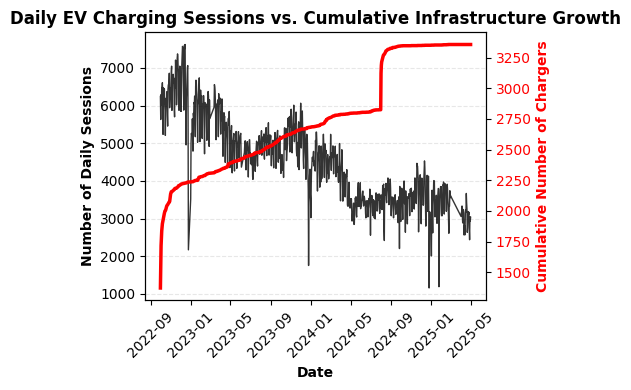

In [22]:
# Group by day to get unique CPIDs per day
daily_groups = data2.groupby('Start')['CPID'].unique()
# 2. Efficiently calculate cumulative unique chargers
cumulative_unique_ids = set()
cumulative_counts_list = []
for date, cpids in daily_groups.items():
    cumulative_unique_ids.update(cpids)
    cumulative_counts_list.append(len(cumulative_unique_ids))
cumulative_df = pd.DataFrame({
    'Start': daily_groups.index,
    'Cumulative_Chargers': cumulative_counts_list
})
# Calculate total sessions per day
sessions_per_day = data2.groupby('Start').size().reset_index(name='session_count')

# Merge data for plotting
plot_data = pd.merge(sessions_per_day, cumulative_df, on='Start', how='left')
# --- PLOTTING (Red & Black Theme) ---
fig, ax1 = plt.subplots(figsize=(5, 4))
# Axis 1: Daily Sessions (Black)
color_sessions = 'black'
ax1.set_xlabel('Date', fontweight='bold')
ax1.set_ylabel('Number of Daily Sessions', color=color_sessions, fontweight='bold')
ax1.plot(plot_data['Start'], plot_data['session_count'], color=color_sessions, linewidth=1, alpha=0.8)
ax1.tick_params(axis='y', labelcolor=color_sessions)
ax1.grid(True, axis='y', linestyle='--', alpha=0.3)
# Rotating date labels for better readability
plt.xticks(rotation=45)
# Axis 2: Cumulative Chargers (Red)
ax2 = ax1.twinx() 
color_chargers = 'red'
ax2.set_ylabel('Cumulative Number of Chargers', color=color_chargers, fontweight='bold')
ax2.plot(plot_data['Start'], plot_data['Cumulative_Chargers'], color=color_chargers, linewidth=2.5)
ax2.tick_params(axis='y', labelcolor=color_chargers)
# Title and Layout
plt.title('Daily EV Charging Sessions vs. Cumulative Infrastructure Growth', fontweight='bold')
fig.tight_layout()

plt.show()

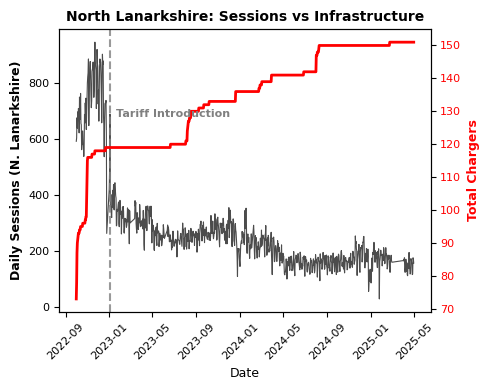

In [23]:
# Filtrage des données pour North Lanarkshire
nlan_data = data2[data2['local_authority'] == 'North Lanarkshire'].copy()
# Calcul des sessions quotidiennes
nlan_sessions = nlan_data.groupby('Start').size().reset_index(name='session_count')
# Calcul des chargeurs cumulés avec logique de set
nlan_daily_ids = nlan_data.groupby('Start')['CPID'].unique()
cum_ids_nlan = set()
cum_counts_nlan = []
for cpids in nlan_daily_ids:
    cum_ids_nlan.update(cpids)
    cum_counts_nlan.append(len(cum_ids_nlan))

nlan_cumulative_df = pd.DataFrame({
    'Start': nlan_daily_ids.index,
    'Cumulative_Chargers': cum_counts_nlan
})
# Fusion des données pour le tracé
nlan_plot_data = pd.merge(nlan_sessions, nlan_cumulative_df, on='Start', how='left')
# Configuration du graphique compact (8x4)
fig, ax1 = plt.subplots(figsize=(5, 4))
# Courbe des Sessions (Noir)
color_sessions = 'black'
ax1.set_xlabel('Date', fontsize=9)
ax1.set_ylabel('Daily Sessions (N. Lanarkshire)', color=color_sessions, fontsize=9, fontweight='bold')
ax1.plot(nlan_plot_data['Start'], nlan_plot_data['session_count'], color=color_sessions, linewidth=0.8, alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color_sessions, labelsize=8)
plt.xticks(rotation=45, fontsize=8)
# Courbe des Chargeurs (Rouge) sur l'axe secondaire
ax2 = ax1.twinx() 
color_chargers = 'red'
ax2.set_ylabel('Total Chargers', color=color_chargers, fontsize=9, fontweight='bold')
ax2.plot(nlan_plot_data['Start'], nlan_plot_data['Cumulative_Chargers'], color=color_chargers, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color_chargers, labelsize=8)
# Ajout de l'indicateur de tarif
tariff_date = pd.to_datetime('2023-01-04')
ax1.axvline(tariff_date, color='grey', linestyle='--', linewidth=1.5, alpha=0.8)
# Annotation du tarif
ax2.annotate('Tariff Introduction', 
             xy=(tariff_date, nlan_plot_data['Cumulative_Chargers'].max() * 0.8), 
             xytext=(pd.to_datetime('2023-01-20'), nlan_plot_data['Cumulative_Chargers'].max() * 0.85),
             fontsize=8, fontweight='bold', color='grey')
plt.title('North Lanarkshire: Sessions vs Infrastructure', fontsize=10, fontweight='bold')
fig.tight_layout()
plt.show()

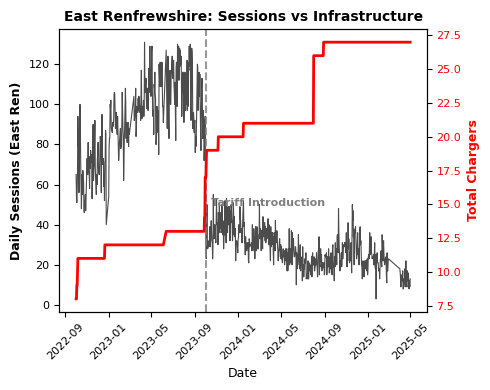

In [24]:
# Filter data for East Renfrewshire
east_ren_data = data2[data2['local_authority'] == 'East Renfrewshire'].copy()
# Calculate daily sessions
east_ren_sessions = east_ren_data.groupby('Start').size().reset_index(name='session_count')
# Calculate cumulative chargers using efficient set logic
east_ren_daily_ids = east_ren_data.groupby('Start')['CPID'].unique()
cum_ids_east_ren = set()
cum_counts_east_ren = []
for cpids in east_ren_daily_ids:
    cum_ids_east_ren.update(cpids)
    cum_counts_east_ren.append(len(cum_ids_east_ren))

east_ren_cumulative_df = pd.DataFrame({
    'Start': east_ren_daily_ids.index,
    'Cumulative_Chargers': cum_counts_east_ren
})
# Merge data for plotting
east_ren_plot_data = pd.merge(east_ren_sessions, east_ren_cumulative_df, on='Start', how='left')
# Compact plotting (8x4)
fig, ax1 = plt.subplots(figsize=(5, 4))
# Sessions Curve (Black)
color_sessions = 'black'
ax1.set_xlabel('Date', fontsize=9)
ax1.set_ylabel('Daily Sessions (East Ren)', color=color_sessions, fontsize=9, fontweight='bold')
ax1.plot(east_ren_plot_data['Start'], east_ren_plot_data['session_count'], color=color_sessions, linewidth=0.8, alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color_sessions, labelsize=8)
plt.xticks(rotation=45, fontsize=8)
# Chargers Curve (Red) on secondary axis
ax2 = ax1.twinx() 
color_chargers = 'red'
ax2.set_ylabel('Total Chargers', color=color_chargers, fontsize=9, fontweight='bold')
ax2.plot(east_ren_plot_data['Start'], east_ren_plot_data['Cumulative_Chargers'], color=color_chargers, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color_chargers, labelsize=8)
# Tariff indicator for East Renfrewshire (Oct 2023)
tariff_date_er = pd.to_datetime('2023-10-01')
ax1.axvline(tariff_date_er, color='grey', linestyle='--', linewidth=1.5, alpha=0.8)
# Position annotation relative to the charger count
ax2.annotate('Tariff Introduction', 
             xy=(tariff_date_er, east_ren_plot_data['Cumulative_Chargers'].max() * 0.5), 
             xytext=(pd.to_datetime('2023-10-15'), east_ren_plot_data['Cumulative_Chargers'].max() * 0.55),
             fontsize=8, fontweight='bold', color='grey')

plt.title('East Renfrewshire: Sessions vs Infrastructure', fontsize=10, fontweight='bold')
fig.tight_layout()
plt.show()

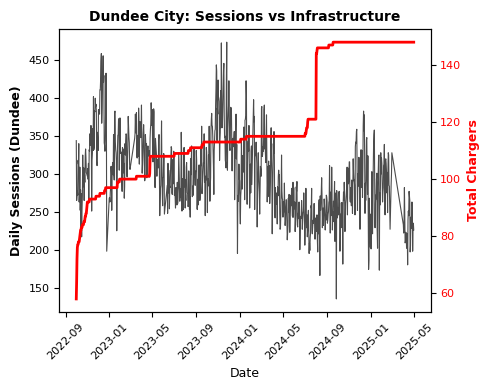

In [25]:
# Filter data for Dundee City
dundee_data = data2[data2['local_authority'] == 'Dundee City'].copy()
# Calculate daily sessions
dundee_sessions = dundee_data.groupby('Start').size().reset_index(name='session_count')
# Calculate cumulative chargers using efficient set logic
dundee_daily_ids = dundee_data.groupby('Start')['CPID'].unique()
cum_ids_dundee = set()
cum_counts_dundee = []
for cpids in dundee_daily_ids:
    cum_ids_dundee.update(cpids)
    cum_counts_dundee.append(len(cum_ids_dundee))
dundee_cumulative_df = pd.DataFrame({
    'Start': dundee_daily_ids.index,
    'Cumulative_Chargers': cum_counts_dundee
})
# Merge data for plotting
dundee_plot_data = pd.merge(dundee_sessions, dundee_cumulative_df, on='Start', how='left')
# Compact plotting (8x4)
fig, ax1 = plt.subplots(figsize=(5, 4))
# Sessions Curve (Black)
color_sessions = 'black'
ax1.set_xlabel('Date', fontsize=9)
ax1.set_ylabel('Daily Sessions (Dundee)', color=color_sessions, fontsize=9, fontweight='bold')
ax1.plot(dundee_plot_data['Start'], dundee_plot_data['session_count'], color=color_sessions, linewidth=0.8, alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color_sessions, labelsize=8)
plt.xticks(rotation=45, fontsize=8)
# Chargers Curve (Red) on secondary axis
ax2 = ax1.twinx() 
color_chargers = 'red'
ax2.set_ylabel('Total Chargers', color=color_chargers, fontsize=9, fontweight='bold')
ax2.plot(dundee_plot_data['Start'], dundee_plot_data['Cumulative_Chargers'], color=color_chargers, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color_chargers, labelsize=8)
plt.title('Dundee City: Sessions vs Infrastructure', fontsize=10, fontweight='bold')
fig.tight_layout()
plt.show()

In [28]:
# Load the file from the CPID_information directory
public_private = pd.read_excel(cpid_path / 'CPID_public_private.xlsx')
# Select only the necessary columns (CPID and the status)
# This excludes 'Postcode' and any other unwanted columns
public_private = public_private[['CPID', 'public/prive']]
# Robust CPID-to-string conversion for public_private
public_private['CPID'] = public_private['CPID'].apply(
    lambda x: str(int(x)) if pd.api.types.is_number(x) and pd.notnull(x) and float(x).is_integer() else str(x)
)
# Ensure CPID in the dataset (data2) is also a string
data2['CPID'] = data2['CPID'].astype(str)
# Merge only the classification status
data2 = pd.merge(data2, public_private, on='CPID', how='left')
# Verification
print("Merge completed: Only 'public/prive' status was added.")
print(f"Current columns in data2: {data2.columns.tolist()}")

Merge completed: Only 'public/prive' status was added.
Current columns in data2: ['CPID', 'Consumed(kWh)', 'Duration', 'Start', 'Time', 'Amount', 'local_authority', 'Postcode', 'Connector_Type', 'public/prive']


In [29]:
master=data2.copy()
# Create 'is_free' column: 'yes' if Amount is 0, else 'no'
master['is_free'] = np.where(master['Amount'] == 0, 'yes', 'no')
# Final verification
print("Merge and 'is_free' tagging completed.")
print(master[['CPID', 'Amount', 'is_free', 'public/prive']].head())

Merge and 'is_free' tagging completed.
       CPID  Amount is_free public/prive
0     50928     0.0     yes       Public
1     52470     0.0     yes       Public
2     10076     0.0     yes          NaN
3     51893     0.0     yes       Public
4  APT51410     0.0     yes          NaN


In [31]:
master.head()

,CPID,Consumed(kWh),Duration,Start,Time,Amount,local_authority,Postcode,Connector_Type,public/prive,is_free
0,50928,107.07,12:30:56,2022-10-01,19:21:26,0.0,South Lanarkshire,ML3 7BL,Rapid,Public,yes
1,52470,106.70,02:53:40,2022-10-02,02:05:12,0.0,East Ayrshire,KA1 3XF,Rapid,Public,yes
2,10076,93.07,11:26:12,2022-10-02,21:06:08,0.0,Dumfries and Galloway,DG1 1NF,AC,NaN,yes
3,51893,92.37,12:33:33,2022-10-01,21:13:11,0.0,City of Edinburgh,EH16 5AY,AC,Public,yes
4,APT51410,85.81,18:11:06,2022-10-02,16:26:37,0.0,Perth and Kinross,PH7 3LQ,AC,NaN,yes


In [33]:
# Save master dataset to the proper output folder
output_path = OUTPUT_DIR / 'master.csv'
master.to_csv(output_path, index=False, encoding='utf-8')
print(f"Saved master.csv → {output_path}")

Saved master.csv → C:\Users\Lenovo\Downloads\Spatio-Temporal-Modelling-of-Electric-Vehicle-Charging-Demand\data\Master file scotland dataset\master.csv
